In [18]:
import random
import sys
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import skfuzzy as fuzz
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_swiss_roll
from sklearn.preprocessing import StandardScaler


from pathlib import Path


PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "components").exists():
    for parent in PROJECT_ROOT.parents:
        if (parent / "components").exists():
            PROJECT_ROOT = parent
            break
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from components.models import ANFISSimple, init_mf_params

In [19]:
# ---------------------------
# 1) Preparing the Swiss roll data
# ---------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)


def make_swiss_roll_binary(n_samples=3000, swiss_noise=0.4):
    X3d, t = make_swiss_roll(n_samples=n_samples, noise=swiss_noise, random_state=SEED)
    labels = (t > np.median(t)).astype(np.int64)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X3d).astype(np.float32)
    return X_scaled, labels


X, y = make_swiss_roll_binary()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, shuffle=True
)



In [20]:
# ---------------------------
# 5) Training (BCE + RMSE tracking)
# ---------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

y_train_tensor = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1).to(device)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1).to(device)
X_train_tensor = torch.tensor(X_train, dtype=torch.float32).to(device)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)

K = 2
init_method = "fcm"  # choose: "fcm", "random_uniform"
centers_init, spreads_init = init_mf_params(X_train, K, method=init_method, scale=1.0)

model = ANFISSimple(centers_init, spreads_init).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.BCEWithLogitsLoss()

n_epochs = 1200
best_loss = float("inf")
best_state = None

for epoch in range(1, n_epochs + 1):
    model.train()
    optimizer.zero_grad()
    logits = model(X_train_tensor)
    loss = loss_fn(logits, y_train_tensor)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
    optimizer.step()

    if loss.item() < best_loss:
        best_loss = loss.item()
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    if epoch % 150 == 0 or epoch == 1:
        model.eval()
        with torch.no_grad():
            train_prob = torch.sigmoid(model(X_train_tensor))
            test_prob = torch.sigmoid(model(X_test_tensor))

            train_pred = (train_prob >= 0.5).float()
            test_pred = (test_prob >= 0.5).float()

            train_total = y_train_tensor.numel()
            test_total = y_test_tensor.numel()
            train_correct = int((train_pred == y_train_tensor).sum().item())
            test_correct = int((test_pred == y_test_tensor).sum().item())
            train_acc = train_correct / train_total
            test_acc = test_correct / test_total
            train_err = 1.0 - train_acc
            test_err = 1.0 - test_acc

        print(
            f"Epoch {epoch:04d}/{n_epochs}  Loss {loss.item():.4f}  "
            f"Train Acc {train_acc:.3f} (Err {train_err:.3f})  "
            f"Test Acc {test_acc:.3f} (Err {test_err:.3f})"
        )

if best_state is not None:
    model.load_state_dict(best_state)
model.eval()

with torch.no_grad():
    final_train_prob = torch.sigmoid(model(X_train_tensor)).cpu().numpy().reshape(-1)
    final_test_prob = torch.sigmoid(model(X_test_tensor)).cpu().numpy().reshape(-1)


def summarize_split(name, probs, labels):
    preds = (probs >= 0.5).astype(np.int64)
    total = len(labels)
    correct = int((preds == labels).sum())
    wrong = total - correct
    accuracy = correct / total
    error = wrong / total
    print(
        f"{name}: accuracy rate {accuracy:.3f} ({correct}/{total} correct points) | "
        f"error {error:.3f} ({wrong} wrong points)"
    )


print("\nFinal Results:")
summarize_split("Train", final_train_prob, y_train)
summarize_split("Test", final_test_prob, y_test)



Epoch 0001/1200  Loss 0.7218  Train Acc 0.394 (Err 0.606)  Test Acc 0.398 (Err 0.602)
Epoch 0150/1200  Loss 0.6770  Train Acc 0.664 (Err 0.336)  Test Acc 0.677 (Err 0.323)
Epoch 0300/1200  Loss 0.6232  Train Acc 0.764 (Err 0.236)  Test Acc 0.760 (Err 0.240)
Epoch 0450/1200  Loss 0.5540  Train Acc 0.855 (Err 0.145)  Test Acc 0.857 (Err 0.143)
Epoch 0600/1200  Loss 0.4879  Train Acc 0.873 (Err 0.127)  Test Acc 0.873 (Err 0.127)
Epoch 0750/1200  Loss 0.4339  Train Acc 0.890 (Err 0.110)  Test Acc 0.897 (Err 0.103)
Epoch 0900/1200  Loss 0.3895  Train Acc 0.910 (Err 0.090)  Test Acc 0.918 (Err 0.082)
Epoch 1050/1200  Loss 0.3495  Train Acc 0.926 (Err 0.074)  Test Acc 0.923 (Err 0.077)
Epoch 1200/1200  Loss 0.3103  Train Acc 0.945 (Err 0.055)  Test Acc 0.938 (Err 0.062)

Final Results:
Train: accuracy rate 0.945 (2268/2400 correct points) | error 0.055 (132 wrong points)
Test: accuracy rate 0.938 (563/600 correct points) | error 0.062 (37 wrong points)


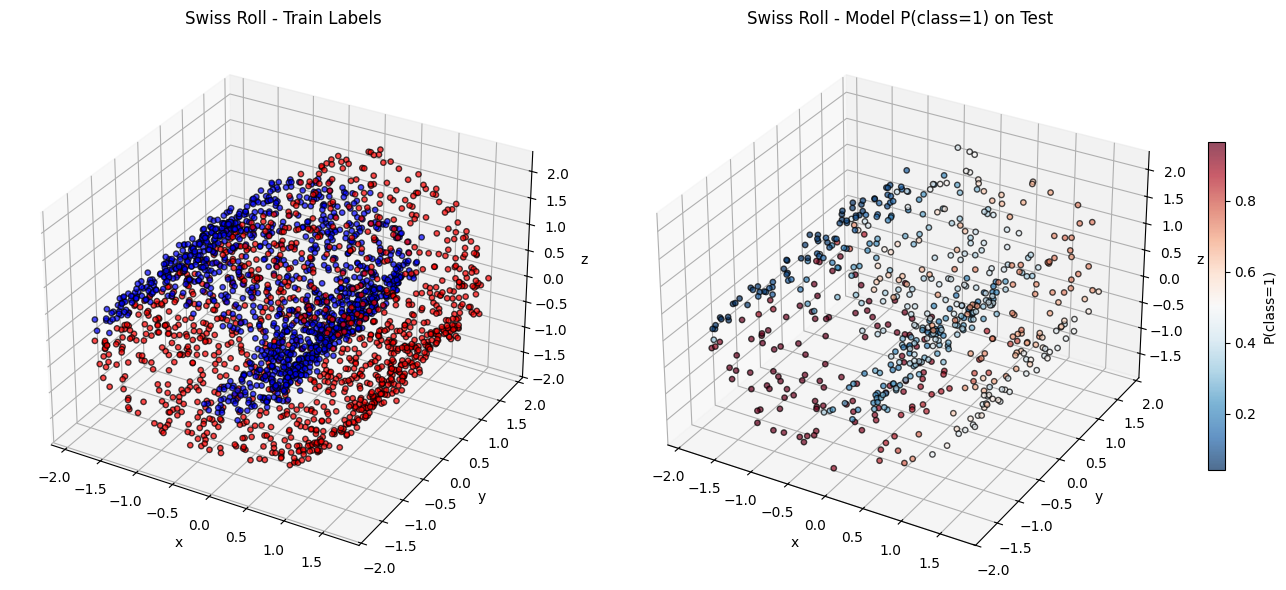

In [21]:
# ---------------------------
# 6) Visualization in 3D space
# ---------------------------
with torch.no_grad():
    train_prob_vis = torch.sigmoid(model(X_train_tensor)).cpu().numpy().reshape(-1)
    test_prob_vis = torch.sigmoid(model(X_test_tensor)).cpu().numpy().reshape(-1)

fig = plt.figure(figsize=(14, 6))
ax1 = fig.add_subplot(1, 2, 1, projection="3d")
ax1.scatter(
    X_train[:, 0],
    X_train[:, 1],
    X_train[:, 2],
    c=y_train,
    cmap="bwr",
    s=15,
    edgecolor="k",
    alpha=0.7,
)
ax1.set_title("Swiss Roll - Train Labels")
ax1.set_xlabel("x")
ax1.set_ylabel("y")
ax1.set_zlabel("z")

ax2 = fig.add_subplot(1, 2, 2, projection="3d")
scatter = ax2.scatter(
    X_test[:, 0],
    X_test[:, 1],
    X_test[:, 2],
    c=test_prob_vis,
    cmap="RdBu_r",
    s=15,
    edgecolor="k",
    alpha=0.7,
)
ax2.set_title("Swiss Roll - Model P(class=1) on Test")
ax2.set_xlabel("x")
ax2.set_ylabel("y")
ax2.set_zlabel("z")
fig.colorbar(scatter, ax=ax2, shrink=0.6, label="P(class=1)")
plt.tight_layout()
plt.show()

